<a href="https://colab.research.google.com/github/ashwithareddykatta-code/sentiment-analysis-projects/blob/main/task_13_Social_Media_Sentiment_%26_Trend_Analytics_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn streamlit pyngrok textblob wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import pandas as pd

data = {
    "text": [
        "I love this product! #awesome",
        "Worst service ever, totally disappointed #fail",
        "This is okay, nothing special #average",
        "Amazing experience! Highly recommend #happy",
        "Terrible behavior by customer support #angry",
        "Great quality and fast delivery #satisfied",
        "I hate this app, very buggy #frustrated",
        "Best purchase ever! #excited",
        "Not good, waste of money #bad",
        "Fantastic service and friendly staff #love"
    ]
}

df = pd.DataFrame(data)
df.head()

,text
0,I love this product! #awesome
1,"Worst service ever, totally disappointed #fail"
2,"This is okay, nothing special #average"
3,Amazing experience! Highly recommend #happy
4,Terrible behavior by customer support #angry


In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required resources (safe to run every time)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Load stopwords
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z#]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df['tokens'] = df['text'].apply(preprocess)
df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,tokens
0,I love this product! #awesome,"[love, product, #, awesome]"
1,"Worst service ever, totally disappointed #fail","[worst, service, ever, totally, disappointed, ..."
2,"This is okay, nothing special #average","[okay, nothing, special, #, average]"
3,Amazing experience! Highly recommend #happy,"[amazing, experience, highly, recommend, #, ha..."
4,Terrible behavior by customer support #angry,"[terrible, behavior, customer, support, #, angry]"


In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['text'].apply(get_sentiment)

df.head()

,text,tokens,sentiment
0,I love this product! #awesome,"[love, product, #, awesome]",Positive
1,"Worst service ever, totally disappointed #fail","[worst, service, ever, totally, disappointed, ...",Negative
2,"This is okay, nothing special #average","[okay, nothing, special, #, average]",Positive
3,Amazing experience! Highly recommend #happy,"[amazing, experience, highly, recommend, #, ha...",Positive
4,Terrible behavior by customer support #angry,"[terrible, behavior, customer, support, #, angry]",Negative


In [ ]:
import re
from collections import Counter

hashtags = []

for text in df['text']:
    hashtags.extend(re.findall(r"#\w+", text.lower()))

hashtag_freq = Counter(hashtags)

trend_df = pd.DataFrame(hashtag_freq.items(), columns=['hashtag', 'count'])
trend_df = trend_df.sort_values(by='count', ascending=False)

trend_df.head()

,hashtag,count
0,#awesome,1
1,#fail,1
2,#average,1
3,#happy,1
4,#angry,1


In [ ]:
toxic_words = ["hate", "worst", "terrible", "angry", "bad"]

def detect_toxic(text):
    return any(word in text.lower() for word in toxic_words)

df['toxic'] = df['text'].apply(detect_toxic)

df.head()

,text,tokens,sentiment,toxic
0,I love this product! #awesome,"[love, product, #, awesome]",Positive,False
1,"Worst service ever, totally disappointed #fail","[worst, service, ever, totally, disappointed, ...",Negative,True
2,"This is okay, nothing special #average","[okay, nothing, special, #, average]",Positive,False
3,Amazing experience! Highly recommend #happy,"[amazing, experience, highly, recommend, #, ha...",Positive,False
4,Terrible behavior by customer support #angry,"[terrible, behavior, customer, support, #, angry]",Negative,True


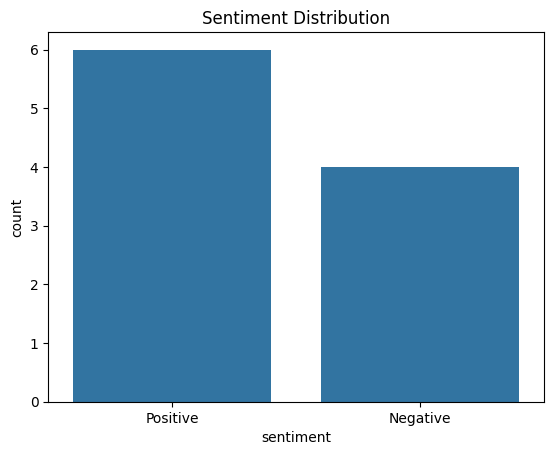

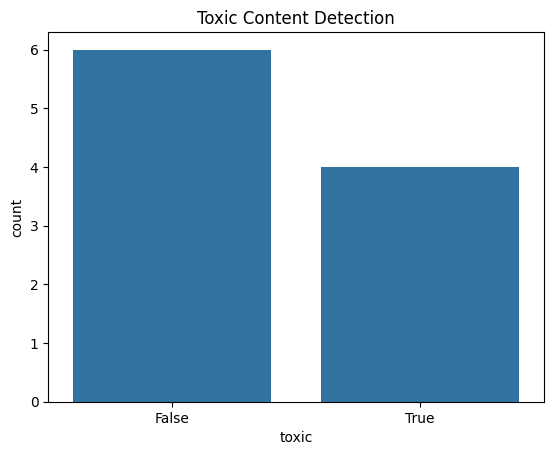

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

plt.figure()
sns.countplot(x='toxic', data=df)
plt.title("Toxic Content Detection")
plt.show()